In [28]:
from datasets import load_dataset
import PIL
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

import torch.nn as nn
import torch
from torchinfo import summary
import torchvision.models as models
from torchvision import transforms 
import torch.optim as optim

torch.manual_seed(42)

In [ ]:
dataset = load_dataset("docling-project/USPTO-30K")
clean = dataset["clean"]

In [58]:
exemple = dataset['clean'][1]
image = exemple['image']

In [89]:
def pad(image, height=2547, width=2573): 
    h, w = image.size[1], image.size[0]
    hp = int((height - h) / 2)
    wp = int((width - w) / 2)

    # Afegeix 1 més de padding en el cas que sigui parell
    if hp % 2: hp+=1
    if wp % 2: wp+=1

    padding = (wp, hp)
    t = transforms.Pad(padding, fill=255)
    return t(image)
    

In [ ]:
def _preprocess_image(pil_image, input_dim=224, image_channels=3):
        """Preprocessament correcte de la imatge de molècula."""
        
        # 1. Converteix a escala de grisos
        img = pil_image.convert('L')  # L = grayscale PIL
        
        # 2. Binaritza: píxels >128 → 255 (blanc), <=128 → 0 (negre)
        threshold = 128
        img = img.point(lambda p: 255 if p > threshold else 0)
        
        # 3. Resize PROPORCIONAL amb canvas blanc
        # No deforma la molècula, l'encaixa en un quadrat blanc
        target_size = input_dim
        original_w, original_h = img.size
        
        # Calcula escala mantenint proporció
        scale = min(target_size / original_w, target_size / original_h)
        new_w = int(original_w * scale)
        new_h = int(original_h * scale)
        
        img_resized = img.resize((new_w, new_h), Image.LANCZOS)
        
        # Crea canvas blanc i centra la imatge
        canvas = Image.new('L', (target_size, target_size), 255)  # 255=blanc
        offset_x = (target_size - new_w) // 2
        offset_y = (target_size - new_h) // 2
        canvas.paste(img_resized, (offset_x, offset_y))
        
        # 4. Converteix a RGB (duplica el canal gris 3 vegades)
        if image_channels == 3:
            canvas = canvas.convert('RGB')  # PIL duplica automàticament el canal
        
        # 5. Converteix a tensor [0,1]
        import torchvision.transforms.functional as TF
        tensor = TF.to_tensor(canvas)  # [0, 255] → [0.0, 1.0]
        
        # 6. Normalitza de [0,1] a [-1,1]: x*2 - 1
        tensor = tensor * 2.0 - 1.0
        
        return tensor

In [93]:
for i, ex in enumerate(clean): 
    print(i, ex['image'].size)

0 (359, 311)
1 (691, 533)
2 (511, 184)
3 (554, 212)
4 (639, 401)
5 (572, 317)
6 (332, 154)
7 (611, 268)
8 (482, 576)
9 (403, 236)
10 (947, 385)
11 (419, 521)
12 (740, 212)
13 (515, 260)
14 (324, 415)
15 (1190, 896)
16 (637, 448)
17 (643, 476)
18 (458, 479)
19 (338, 384)
20 (445, 522)
21 (444, 754)
22 (623, 656)
23 (922, 470)
24 (1311, 305)
25 (779, 348)
26 (233, 273)
27 (624, 264)
28 (623, 414)
29 (657, 361)
30 (619, 389)
31 (857, 335)
32 (691, 372)
33 (750, 485)
34 (910, 346)
35 (602, 280)
36 (532, 419)
37 (380, 360)
38 (648, 221)
39 (890, 554)
40 (579, 592)
41 (736, 155)
42 (820, 313)
43 (1205, 588)
44 (1245, 537)
45 (631, 416)
46 (566, 447)
47 (535, 387)
48 (833, 591)
49 (800, 350)
50 (591, 773)
51 (665, 428)
52 (1098, 351)
53 (614, 458)
54 (518, 652)
55 (327, 401)
56 (327, 137)
57 (816, 499)
58 (430, 612)
59 (707, 458)
60 (885, 257)
61 (872, 823)
62 (725, 380)
63 (417, 544)
64 (578, 852)
65 (886, 428)
66 (528, 567)
67 (892, 286)
68 (647, 617)
69 (1509, 337)
70 (825, 280)
71 (582, 4

KeyboardInterrupt: 

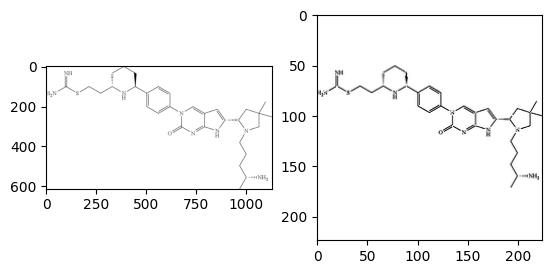

In [95]:
test = clean[750:750+1]['image']

for image in test:
    tensor_tr = _preprocess_image(image)
    # tensor_pad = pad(image)
    t = transforms.ToPILImage(mode='RGB')
    pil_tr = t(tensor_tr)
    
    _, ax = plt.subplots(1, 2)
    # _, ax = plt.subplots(1, 3)
    ax[0].imshow(image)
    ax[1].imshow(pil_tr)
    # ax[2].imshow(tensor_pad)
    plt.show()